In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist
from scipy.stats import entropy
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ All imports successful!")

Matplotlib is building the font cache; this may take a moment.


✅ All imports successful!


In [2]:
# Create synthetic microbiome data
np.random.seed(42)
n_samples = 100
n_bacteria = 50

# Create abundance table
abundance_data = np.random.multinomial(10000, np.ones(n_bacteria)/n_bacteria, n_samples)

# Convert to DataFrame
abundance_df = pd.DataFrame(
    abundance_data,
    columns=[f'Bacteria_{i}' for i in range(n_bacteria)]
)

print("✅ Data created!")
print(f"Shape: {abundance_df.shape}")

✅ Data created!
Shape: (100, 50)


In [3]:
# Shannon diversity
def shannon_diversity(sample):
    relative = sample / sample.sum()
    relative = relative[relative > 0]
    return entropy(relative, base=2)

shannon_indices = abundance_df.apply(shannon_diversity, axis=1)

# Simpson diversity
def simpson_diversity(sample):
    relative = sample / sample.sum()
    return 1 - np.sum(relative**2)

simpson_indices = abundance_df.apply(simpson_diversity, axis=1)

# Store in DataFrame
diversity_df = pd.DataFrame({
    'sample_id': range(n_samples),
    'shannon': shannon_indices,
    'simpson': simpson_indices
})

print("✅ Diversity metrics calculated!")
print(diversity_df.head())

✅ Diversity metrics calculated!
   sample_id   shannon   simpson
0          0  5.639918  0.979891
1          1  5.639330  0.979874
2          2  5.639826  0.979889
3          3  5.639532  0.979879
4          4  5.640375  0.979904


✅ Plot 1 saved!


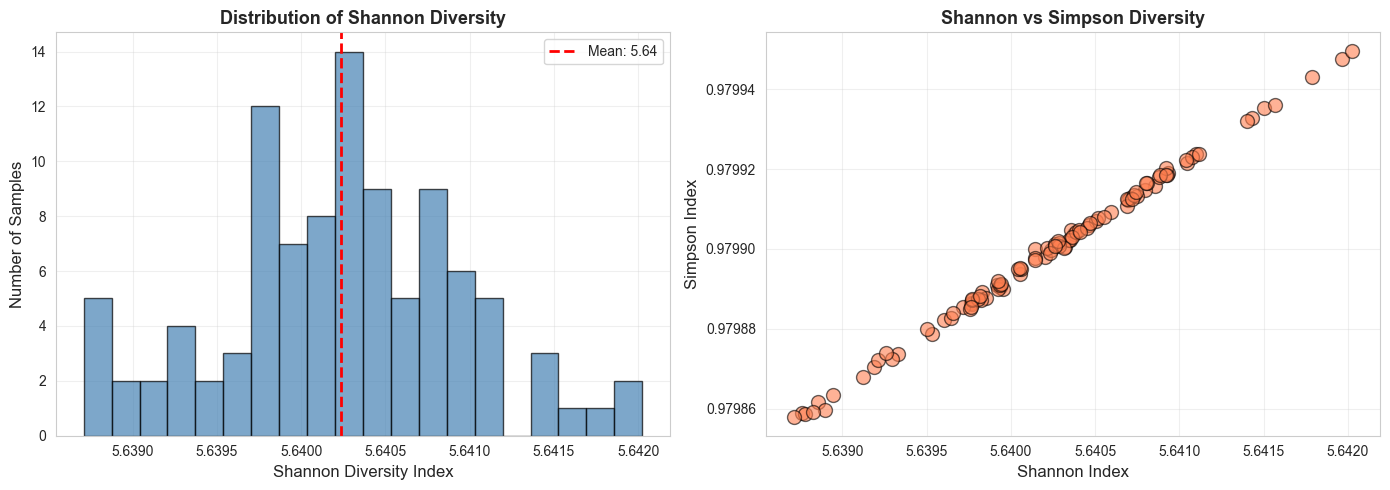

In [4]:
# PLOT 1: Diversity Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(shannon_indices, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Shannon Diversity Index', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].set_title('Distribution of Shannon Diversity', fontsize=13, fontweight='bold')
axes[0].axvline(shannon_indices.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {shannon_indices.mean():.2f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(shannon_indices, simpson_indices, alpha=0.6, s=100, color='coral', edgecolor='black')
axes[1].set_xlabel('Shannon Index', fontsize=12)
axes[1].set_ylabel('Simpson Index', fontsize=12)
axes[1].set_title('Shannon vs Simpson Diversity', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/01_diversity_distribution.png', dpi=300, bbox_inches='tight')
print("✅ Plot 1 saved!")
plt.show()

In [5]:
import os
from datetime import datetime

# Create results directory
os.makedirs('../results', exist_ok=True)

# Save diversity metrics to CSV
diversity_df.to_csv('../results/diversity_metrics_week1.csv', index=False)
print("✅ Saved: diversity_metrics_week1.csv")

# Save abundance statistics
abundance_stats = abundance_df.describe().T
abundance_stats.to_csv('../results/abundance_statistics.csv')
print("✅ Saved: abundance_statistics.csv")

# Create summary report
summary_report = f"""
# WEEK 1 ANALYSIS SUMMARY
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

## Data Overview
- Total samples: {len(diversity_df)}
- Total bacteria: {abundance_df.shape[1]}
- Shannon diversity (mean ± std): {shannon_indices.mean():.2f} ± {shannon_indices.std():.2f}
- Simpson diversity (mean ± std): {simpson_indices.mean():.2f} ± {simpson_indices.std():.2f}

## Top 5 Most Abundant Bacteria
{abundance_df.mean().nlargest(5).to_string()}

## Plots Generated
1. 01_diversity_distribution.png

## Status
✅ Week 1 analysis complete!
"""

with open('../results/WEEK1_SUMMARY.txt', 'w') as f:
    f.write(summary_report)

print("✅ Saved: WEEK1_SUMMARY.txt")
print("\n" + "="*50)
print("WEEK 1 ANALYSIS COMPLETE!")
print("="*50)

✅ Saved: diversity_metrics_week1.csv
✅ Saved: abundance_statistics.csv
✅ Saved: WEEK1_SUMMARY.txt

WEEK 1 ANALYSIS COMPLETE!
